In [13]:
!pip install -q scikit-learn pandas numpy

import numpy as np
import pandas as pd

from dataclasses import dataclass

from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [21]:
from sklearn.metrics import accuracy_score

train_pred = tuned_rf.predict(X_train)
test_pred = tuned_rf.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9833333333333333
Test Accuracy: 0.9666666666666667


In [22]:
@dataclass
class ModelResult:
    name: str
    accuracy: float
    f1_macro: float


def load_data(test_size: float = 0.2, random_state: int = 42):
    iris = load_iris(as_frame=True)
    X = iris.data
    y = iris.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print("Features:", list(X.columns))
    return X_train, X_test, y_train, y_test

In [23]:
def evaluate_model(model, X_test, y_test, name: str) -> ModelResult:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-macro: {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    return ModelResult(name=name, accuracy=acc, f1_macro=f1)

In [24]:
def baseline_random_forest(X_train, X_test, y_train, y_test) -> ModelResult:
    # Baseline: default RandomForestClassifier
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    return evaluate_model(
        rf, X_test, y_test,
        name="Baseline Random Forest (default hyperparams)",
    )

In [25]:
def tuned_random_forest(X_train, X_test, y_train, y_test) -> tuple[ModelResult, RandomForestClassifier]:
    rf = RandomForestClassifier(random_state=42)

    param_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 3, 5, 8],
        "max_features": ["sqrt", "log2"],
        "min_samples_split": [2, 4],
    }

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring="f1_macro",
    )

    grid_search.fit(X_train, y_train)

    print("\nBest params for tuned Random Forest:", grid_search.best_params_)

    best_model: RandomForestClassifier = grid_search.best_estimator_
    result = evaluate_model(
        best_model, X_test, y_test,
        name="Improved Random Forest (tuned hyperparameters)",
    )
    return result, best_model

**Improved: Feature-selected Random Forest**

In [26]:
def feature_selected_random_forest(
    tuned_rf: RandomForestClassifier,
    X_train, X_test, y_train, y_test
) -> ModelResult:
    # Get feature importances
    importances = tuned_rf.feature_importances_
    feature_names = list(X_train.columns)

    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    print("\nFeature importances from tuned RF:")
    display(importance_df)

    # Keep top 3 features (drop the least important)
    top_features = importance_df["feature"].iloc[:3].tolist()
    print("\nUsing only top features:", top_features)

    X_train_sel = X_train[top_features]
    X_test_sel = X_test[top_features]

    rf_sel = RandomForestClassifier(
        random_state=42,
        n_estimators=tuned_rf.n_estimators,
        max_depth=tuned_rf.max_depth,
        max_features=tuned_rf.max_features,
        min_samples_split=tuned_rf.min_samples_split,
    )

    rf_sel.fit(X_train_sel, y_train)

    return evaluate_model(
        rf_sel, X_test_sel, y_test,
        name="Improved Random Forest (tuned + feature selection)",
    )

**Comparison Between both untuned & tuned**

In [27]:
def print_comparison(results: list[ModelResult]):
    print("\n================ COMPARISON SUMMARY ================")
    df = pd.DataFrame(
        [
            {"Model": r.name, "Accuracy": r.accuracy, "F1_macro": r.f1_macro}
            for r in results
        ]
    )
    display(df)

    baseline = results[0]
    print("\nShort numeric write-up:")
    for r in results[1:]:
        acc_delta = r.accuracy - baseline.accuracy
        f1_delta = r.f1_macro - baseline.f1_macro
        print(
            f"- Compared to the baseline, {r.name} improved "
            f"accuracy by {acc_delta:.4f} and F1-macro by {f1_delta:.4f}."
        )

In [28]:
# Load data
X_train, X_test, y_train, y_test = load_data()

results = []

# 1) Baseline RF
baseline_res = baseline_random_forest(X_train, X_test, y_train, y_test)
results.append(baseline_res)

# 2) Improved RF: tuned hyperparameters
tuned_res, tuned_rf = tuned_random_forest(X_train, X_test, y_train, y_test)
results.append(tuned_res)

# 3) Improved RF: tuned + feature selection
feat_sel_res = feature_selected_random_forest(
    tuned_rf, X_train, X_test, y_train, y_test
)
results.append(feat_sel_res)

# Summary and numeric write-up
print_comparison(results)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

=== Baseline Random Forest (default hyperparams) ===
Accuracy: 0.9000
F1-macro: 0.8997

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.8182    0.9000    0.8571        10
           2     0.8889    0.8000    0.8421        10

    accuracy                         0.9000        30
   macro avg     0.9024    0.9000    0.8997        30
weighted avg     0.9024    0.9000    0.8997        30


Best params for tuned Random Forest: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}

=== Improved Random Forest (tuned hyperparameters) ===
Accuracy: 0.9667
F1-macro: 0.9666

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    0.9000    0.9474        10
           2  

,feature,importance
2,petal length (cm),0.444206
3,petal width (cm),0.435467
0,sepal length (cm),0.114296
1,sepal width (cm),0.006031



Using only top features: ['petal length (cm)', 'petal width (cm)', 'sepal length (cm)']

=== Improved Random Forest (tuned + feature selection) ===
Accuracy: 0.9333
F1-macro: 0.9333

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     0.9000    0.9000    0.9000        10
           2     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30


================ COMPARISON SUMMARY ================


,Model,Accuracy,F1_macro
0,Baseline Random Forest (default hyperparams),0.900000,0.899749
1,Improved Random Forest (tuned hyperparameters),0.966667,0.966583
2,Improved Random Forest (tuned + feature select...,0.933333,0.933333



Short numeric write-up:
- Compared to the baseline, Improved Random Forest (tuned hyperparameters) improved accuracy by 0.0667 and F1-macro by 0.0668.
- Compared to the baseline, Improved Random Forest (tuned + feature selection) improved accuracy by 0.0333 and F1-macro by 0.0336.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tuned_rf, X_train, y_train, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.9583333333333334


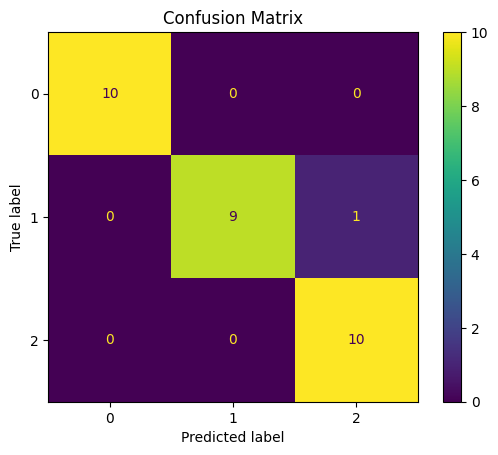

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

             Feature  Importance
2  petal length (cm)    0.444206
3   petal width (cm)    0.435467
0  sepal length (cm)    0.114296
1   sepal width (cm)    0.006031


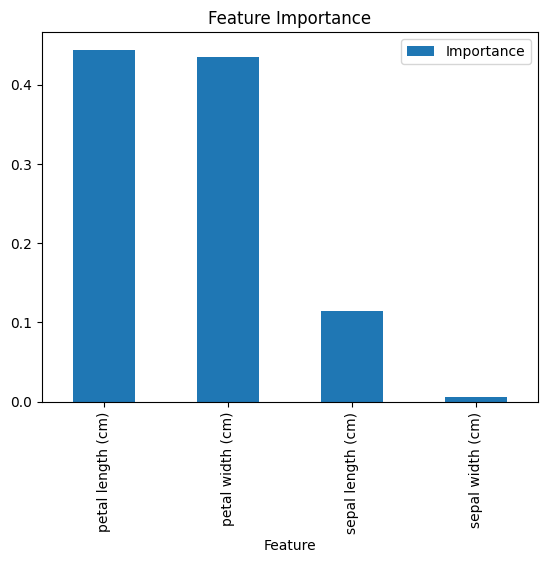

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

importances = tuned_rf.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    title="Feature Importance"
)

plt.show()